# NeuroDetect — Grad-CAM Heatmaps
**Course**: Computer Vision | Christian Mata, PhD

**Dataset**: LGG Brain MRI Segmentation (Kaggle — mateuszbuda)

**Task**: Loads trained CNN from Drive, visualizes which regions the model focuses on.

**Group members**: Martin Çaro, Edison Zyberaj


# Grad-CAM Heatmaps
**Requires 02_classification_TL.** Loads trained CNN from Drive, visualizes which regions the model focuses on.

## 1. Mount Drive and load model

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/CV_Project'
os.makedirs(DRIVE + '/brain/images', exist_ok=True)
os.makedirs(DRIVE + '/brain/masks',  exist_ok=True)
os.makedirs(DRIVE + '/splits',       exist_ok=True)
os.makedirs(DRIVE + '/models',       exist_ok=True)
os.makedirs(DRIVE + '/results',      exist_ok=True)
print('Drive mounted ✓  —  ' + DRIVE)

Mounted at /content/drive
Drive mounted ✓  —  /content/drive/MyDrive/CV_Project


In [ ]:
import os, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import load_model

assert os.path.exists(DRIVE + '/models/brain_tumor_classifier.h5'),     '❌ Run 02_classification_TL.ipynb first.'
assert os.path.exists(DRIVE + '/splits/x_test.npy'),     '❌ Run 01_train_test.ipynb first.'

model       = load_model(DRIVE + '/models/brain_tumor_classifier.h5')
x_test      = np.load(DRIVE + '/splits/x_test.npy')
y_test      = np.load(DRIVE + '/splits/y_test.npy')
label_names = ['no tumor', 'tumor']

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
y_pred = np.argmax(model.predict(x_test), axis=1)

# Find last Conv2D layer name automatically
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break
print(f'Model loaded ✓  |  last Conv2D layer: {last_conv}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Model loaded ✓  |  last Conv2D layer: conv2d_1


## 2. Grad-CAM implementation

In [6]:
def make_gradcam_heatmap(image, model, last_conv_layer_name, pred_index=None):
    image_batch = tf.cast(image[np.newaxis, ...], tf.float32)

    with tf.GradientTape() as tape:
        x            = image_batch
        conv_outputs = None

        for layer in model.layers:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                conv_outputs = x
                tape.watch(conv_outputs)

        predictions = x
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(image, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], (image.shape[0], image.shape[1])
    ).numpy().squeeze()
    colored = plt.cm.jet(heatmap_resized)[..., :3]
    return np.clip((1 - alpha) * np.clip(image, 0, 1) + alpha * colored, 0, 1)

print('Grad-CAM functions ready ✓')

Grad-CAM functions ready ✓


## 3. Visualize — correct predictions (true positives)

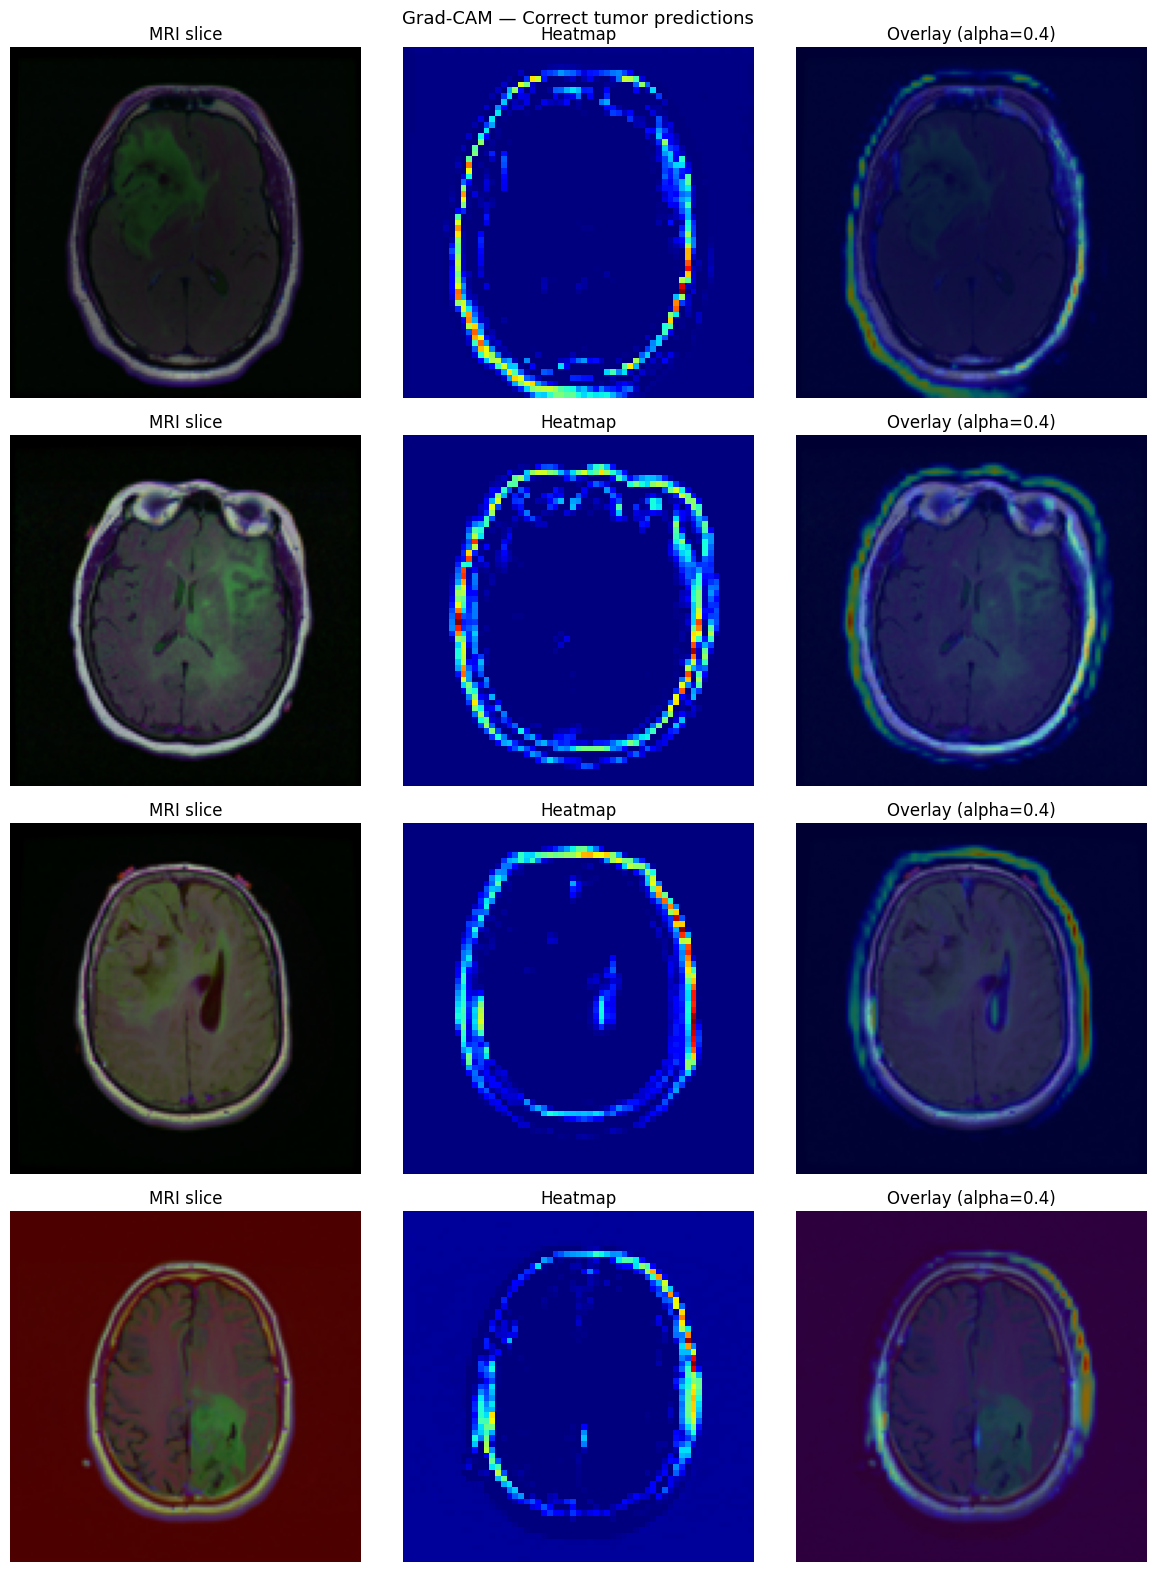

In [8]:
correct_tumor = np.where((y_test == 1) & (y_pred == 1))[0][:4]

fig, axes = plt.subplots(len(correct_tumor), 3, figsize=(12, 4 * len(correct_tumor)))
fig.suptitle('Grad-CAM — Correct tumor predictions', fontsize=13)

for row, idx in enumerate(correct_tumor):
    image   = x_test[idx]
    heatmap = make_gradcam_heatmap(image, model, last_conv)
    overlay = overlay_heatmap(image, heatmap)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title('MRI slice'); axes[row, 0].axis('off')
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title('Heatmap'); axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Overlay (alpha=0.4)'); axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(DRIVE + '/results/gradcam_correct.png', dpi=120)
plt.show()

## 4. Visualize — false negatives (missed tumors)

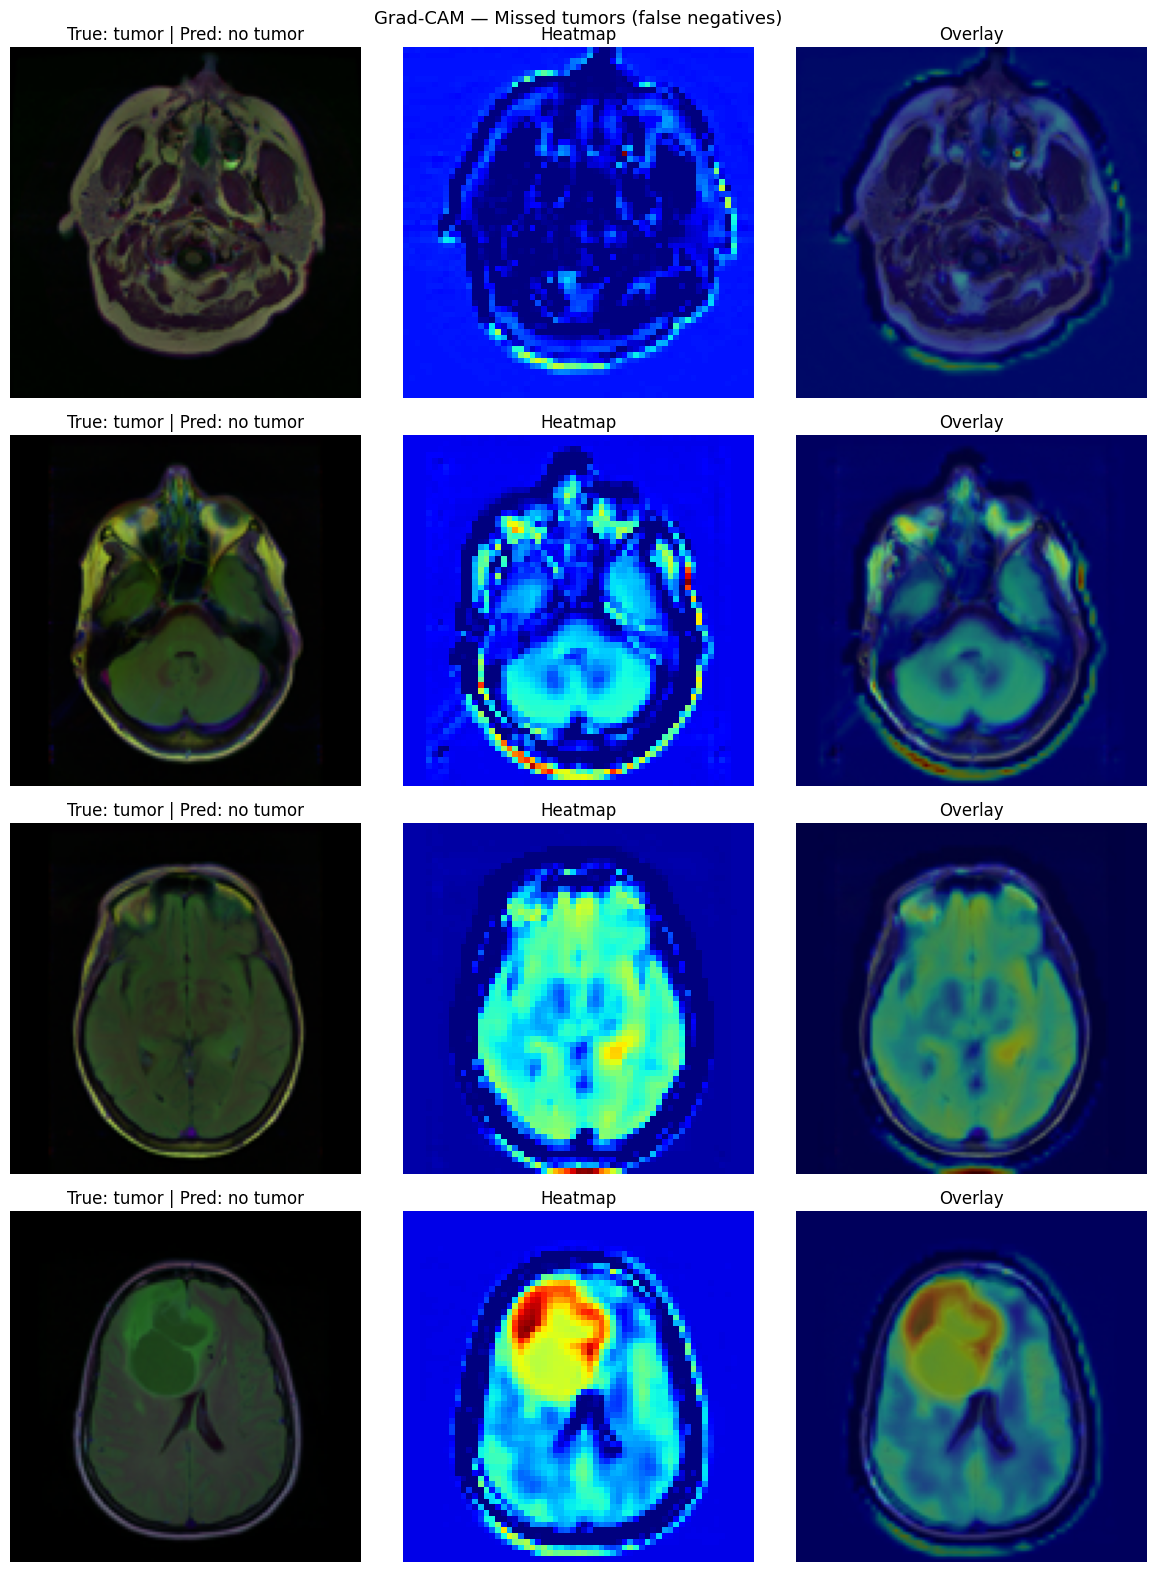

In [9]:
false_neg = np.where((y_test == 1) & (y_pred == 0))[0][:4]

if len(false_neg) == 0:
    print('No false negatives found — the model is performing very well!')
else:
    fig, axes = plt.subplots(len(false_neg), 3, figsize=(12, 4 * len(false_neg)))
    if len(false_neg) == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('Grad-CAM — Missed tumors (false negatives)', fontsize=13)

    for row, idx in enumerate(false_neg):
        image   = x_test[idx]
        heatmap = make_gradcam_heatmap(image, model, last_conv)
        overlay = overlay_heatmap(image, heatmap)

        axes[row, 0].imshow(image)
        axes[row, 0].set_title('True: tumor | Pred: no tumor'); axes[row, 0].axis('off')
        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title('Heatmap'); axes[row, 1].axis('off')
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Overlay'); axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig(DRIVE + '/results/gradcam_false_negatives.png', dpi=120)
    plt.show()

## 5. Discussion

**What Grad-CAM shows.** The heatmap highlights which pixels in the input image contributed most to the model's prediction. Warm colours (red/yellow) = high activation, cool colours (blue) = low. For a correct tumor prediction, the heatmap should focus on the bright region visible in the FLAIR MRI channel. For a false negative, the heatmap often shows the model was looking at the wrong region — background structure rather than the abnormal area.

This kind of error analysis connects directly to classical methods using raw pixel intensity; the CNN learns a *combination* of local patterns, but can still be fooled by ambiguous cases where the tumor has similar appearance to normal tissue.